# Generating Embeddings using Hugging Face (Free models)

**Level:** Scratch → Intermediate
**Runs on:** Google Colab (Free CPU/GPU)

### What you will learn
1. What an embedding is (in simple words)
2. Installing free, open Hugging Face libraries
3. Generating embeddings with `sentence-transformers`
4. Comparing text similarity using cosine similarity
5. Visualizing embeddings in 2D
6. Building a mini Semantic Search engine (intermediate project)

> No API key needed. No paid model used. Everything here runs on the free Hugging Face open-source models.

## 1. What is an Embedding?

- An **embedding** is a list of numbers (a vector) that represents the *meaning* of a piece of text.
- Similar sentences → similar (close) vectors.
- Different sentences → far apart vectors.

Example:
- "I love dogs" and "I like puppies" → vectors will be **close**
- "I love dogs" and "The stock market crashed" → vectors will be **far apart**

We will use the `sentence-transformers` library, which uses free Hugging Face models.

### 2. Install Required Libraries
Run this once. `-q` keeps the output quiet (low token / clean output).

In [1]:
!pip install sentence-transformers

In [2]:
!pip install -q sentence-transformers scikit-learn matplotlib

### 3. Load a Free Hugging Face Model

We are using **`all-MiniLM-L6-v2`** — a small, fast, completely free open-source model from Hugging Face.
- Size: ~80MB
- Great for learning and even production use
- Output: 384-dimensional embedding vector per sentence

In [3]:
from sentence_transformers import SentenceTransformer

# Load the free pre-trained model from Hugging Face
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model loaded successfully!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded successfully!


### 4. Generate Your First Embedding

In [4]:
sentence = "I love learning about Artificial Intelligence."
embedding = model.encode(sentence)
print("Sentence:", sentence)
print("Embedding shape:", embedding.shape)
print("First 10 values:", embedding[:10])

Sentence: I love learning about Artificial Intelligence.
Embedding shape: (384,)
First 10 values: [ 0.01634456 -0.07657032  0.04107471  0.01962835  0.05804767 -0.05071756
  0.03889349  0.03076571  0.05800406  0.06948567]


**Discussion Point:** Notice the embedding has 384 numbers. These numbers don't mean anything individually — but together, they capture the *meaning* of the sentence.

### 5. Generate Embeddings for Multiple Sentences

In [5]:
sentences = [
    "I love dogs",
    "I like puppies",
    "The stock market crashed today",
    "Cats are cute pets",
    "The economy is in recession"
]

embeddings = model.encode(sentences)

print("Number of sentences:", len(sentences))
print("Embedding matrix shape:", embeddings.shape)

Number of sentences: 5
Embedding matrix shape: (5, 384)


### 6. Measure Similarity Between Sentences

We use **Cosine Similarity** to check how close two embeddings are.
- Score close to `1` → very similar meaning
- Score close to `0` → unrelated meaning
- Score close to `-1` → opposite meaning (rare with text)

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

import pandas as pd
df = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df.round(2)

,I love dogs,I like puppies,The stock market crashed today,Cats are cute pets,The economy is in recession
I love dogs,1.00,0.71,0.04,0.51,0.04
I like puppies,0.71,1.00,-0.00,0.48,0.03
The stock market crashed today,0.04,-0.00,1.00,0.05,0.43
Cats are cute pets,0.51,0.48,0.05,1.00,0.06
The economy is in recession,0.04,0.03,0.43,0.06,1.00


**Important Discussion Point:**
Look at the similarity score between *"I love dogs"* and *"I like puppies"* — it should be high.
Compare that to *"I love dogs"* vs *"The stock market crashed today"* — it should be low.

This is the **core idea behind semantic search, chatbots, and recommendation systems**.

### 7. Visualize Embeddings in 2D (using PCA)
Embeddings have 384 dimensions — we can't see that. So we reduce it to 2D just to *visualize* how sentences cluster.

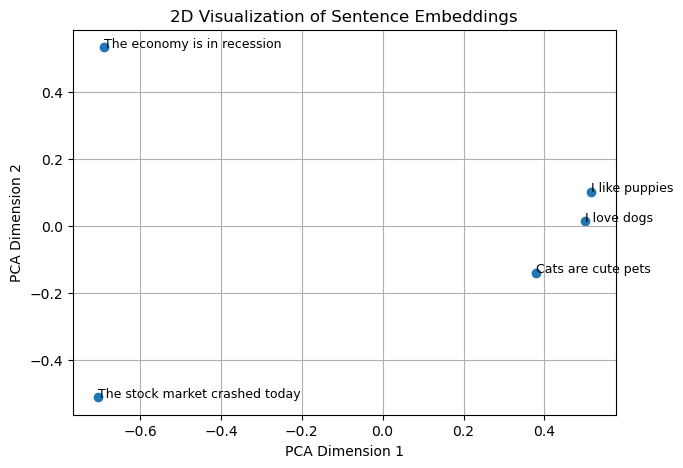

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 5))
plt.scatter(reduced[:, 0], reduced[:, 1])

for i, sent in enumerate(sentences):
    plt.annotate(sent, (reduced[i, 0], reduced[i, 1]), fontsize=9)

plt.title("2D Visualization of Sentence Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()

**Discussion Point:** Sentences with similar meaning (dogs/puppies, stock/economy) should appear **closer together** in the plot, even though we never told the model to group them manually.

## 8. Intermediate Project: Mini Semantic Search Engine

**Goal:** Given a user query, find the most relevant sentence from a small database — using meaning, not just matching words.

In [8]:
# Our small "document" database
documents = [
    "Python is a popular programming language for AI.",
    "The weather today is sunny and warm.",
    "Machine learning models learn patterns from data.",
    "I enjoy playing football on weekends.",
    "Deep learning uses neural networks with many layers.",
    "Paris is the capital city of France."
]

# Encode all documents once
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=2):
    query_embedding = model.encode([query])
    scores = cosine_similarity(query_embedding, doc_embeddings)[0]

    # Rank documents by similarity score
    ranked_idx = scores.argsort()[::-1][:top_k]

    print(f"Query: {query}\n")
    for idx in ranked_idx:
        print(f"Score: {scores[idx]:.3f}  |  {documents[idx]}")

# Try it
semantic_search("Tell me about AI and neural networks")

Query: Tell me about AI and neural networks

Score: 0.534  |  Deep learning uses neural networks with many layers.
Score: 0.524  |  Python is a popular programming language for AI.


In [9]:
# Try another query
semantic_search("What is the capital of France?")

Query: What is the capital of France?

Score: 0.824  |  Paris is the capital city of France.
Score: 0.102  |  Python is a popular programming language for AI.


### 9. Key Takeaways (Recap for Students)

| Concept | Meaning |
|---|---|
| Embedding | Numeric vector representing meaning of text |
| Model used | `all-MiniLM-L6-v2` (free, open-source, Hugging Face) |
| Cosine Similarity | Measures how close two embeddings are |
| Semantic Search | Finding relevant text by meaning, not exact words |
| PCA | Used only to visualize high-dimension vectors in 2D |

### 10. Practice Exercises (for students)
1. Replace the `documents` list with your own 10 sentences and test `semantic_search`.
2. Try a different free model: `'all-mpnet-base-v2'` (more accurate, slightly slower) and compare results.
3. Build a simple FAQ bot: store 5 Q&A pairs, and retrieve the best matching answer for a new question.

In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load the free Hugging Face model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Your own 10 sentences
documents = [
    "Python is a popular programming language.",
    "Java is used for developing many applications.",
    "Artificial Intelligence allows computers to learn.",
    "Machine learning is a part of Artificial Intelligence.",
    "Deep learning uses neural networks.",
    "Football is a popular sport around the world.",
    "Cricket is very popular in India.",
    "Healthy food is important for our body.",
    "Exercise helps us stay physically fit.",
    "Cloud computing provides services over the internet."
]

# Convert documents into embeddings
document_embeddings = model.encode(documents)

# Search function
def semantic_search(query):
    query_embedding = model.encode(query)

    # Calculate cosine similarity
    similarities = np.dot(document_embeddings, query_embedding) / (
        np.linalg.norm(document_embeddings, axis=1) *
        np.linalg.norm(query_embedding)
    )

    # Get indexes of highest similarity
    top_indexes = np.argsort(similarities)[::-1][:3]

    print("\nQuery:", query)
    print("\nTop 3 results:")

    for index in top_indexes:
        print(
            f"{documents[index]}  --> Similarity: {similarities[index]:.4f}"
        )


# Try different searches
semantic_search("I want to learn programming")
semantic_search("How can I become healthy?")
semantic_search("Tell me about AI")
semantic_search("What sports are popular?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Query: I want to learn programming

Top 3 results:
Python is a popular programming language.  --> Similarity: 0.5122
Artificial Intelligence allows computers to learn.  --> Similarity: 0.3594
Java is used for developing many applications.  --> Similarity: 0.3407

Query: How can I become healthy?

Top 3 results:
Healthy food is important for our body.  --> Similarity: 0.5456
Exercise helps us stay physically fit.  --> Similarity: 0.4111
Football is a popular sport around the world.  --> Similarity: 0.0535

Query: Tell me about AI

Top 3 results:
Artificial Intelligence allows computers to learn.  --> Similarity: 0.7048
Machine learning is a part of Artificial Intelligence.  --> Similarity: 0.5845
Deep learning uses neural networks.  --> Similarity: 0.4269

Query: What sports are popular?

Top 3 results:
Football is a popular sport around the world.  --> Similarity: 0.6484
Cricket is very popular in India.  --> Similarity: 0.5101
Python is a popular programming language.  --> Similarity

In [11]:
from sentence_transformers import SentenceTransformer
import numpy as np

documents = [
    "Python is a popular programming language.",
    "Java is used for developing many applications.",
    "Artificial Intelligence allows computers to learn.",
    "Machine learning is a part of Artificial Intelligence.",
    "Deep learning uses neural networks.",
    "Football is a popular sport around the world.",
    "Cricket is very popular in India.",
    "Healthy food is important for our body.",
    "Exercise helps us stay physically fit.",
    "Cloud computing provides services over the internet."
]

query = "I want to learn about artificial intelligence"

# Model 1
model1 = SentenceTransformer("all-MiniLM-L6-v2")

embeddings1 = model1.encode(documents)
query_embedding1 = model1.encode(query)

similarities1 = np.dot(embeddings1, query_embedding1) / (
    np.linalg.norm(embeddings1, axis=1) *
    np.linalg.norm(query_embedding1)
)

print("===== all-MiniLM-L6-v2 =====")

top1 = np.argsort(similarities1)[::-1][:3]

for i in top1:
    print(f"{documents[i]} --> {similarities1[i]:.4f}")


# Model 2
model2 = SentenceTransformer("all-mpnet-base-v2")

embeddings2 = model2.encode(documents)
query_embedding2 = model2.encode(query)

similarities2 = np.dot(embeddings2, query_embedding2) / (
    np.linalg.norm(embeddings2, axis=1) *
    np.linalg.norm(query_embedding2)
)

print("\n===== all-mpnet-base-v2 =====")

top2 = np.argsort(similarities2)[::-1][:3]

for i in top2:
    print(f"{documents[i]} --> {similarities2[i]:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

===== all-MiniLM-L6-v2 =====
Artificial Intelligence allows computers to learn. --> 0.7172
Machine learning is a part of Artificial Intelligence. --> 0.5987
Python is a popular programming language. --> 0.3529


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


===== all-mpnet-base-v2 =====
Artificial Intelligence allows computers to learn. --> 0.6225
Machine learning is a part of Artificial Intelligence. --> 0.4824
Deep learning uses neural networks. --> 0.3213


In [12]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2")

# FAQ questions and answers
faq_questions = [
    "What is Python?",
    "What is Java?",
    "What is Artificial Intelligence?",
    "What is machine learning?",
    "What is an embedding?"
]

faq_answers = [
    "Python is a popular programming language used for web development, data science, AI, and automation.",
    "Java is a programming language commonly used for application and software development.",
    "Artificial Intelligence is the field of creating systems that can perform tasks that normally require human intelligence.",
    "Machine learning is a branch of AI where computers learn patterns from data.",
    "An embedding is a numerical vector that represents the meaning of text."
]

# Convert FAQ questions into embeddings
faq_embeddings = model.encode(faq_questions)


def faq_bot(user_question):

    # Convert user question into embedding
    question_embedding = model.encode(user_question)

    # Calculate cosine similarity
    similarities = np.dot(faq_embeddings, question_embedding) / (
        np.linalg.norm(faq_embeddings, axis=1) *
        np.linalg.norm(question_embedding)
    )

    # Find the most similar question
    best_index = np.argmax(similarities)

    # Similarity score
    score = similarities[best_index]

    print("\nUser:", user_question)
    print("Matched FAQ:", faq_questions[best_index])
    print("Similarity:", round(score, 4))

    # Give the answer
    if score >= 0.40:
        print("Bot:", faq_answers[best_index])
    else:
        print("Bot: Sorry, I don't know the answer to that question.")


# Test the FAQ bot
faq_bot("Can you explain Python?")
faq_bot("Tell me about AI")
faq_bot("What does machine learning mean?")
faq_bot("What are embeddings?")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


User: Can you explain Python?
Matched FAQ: What is Python?
Similarity: 0.7577
Bot: Python is a popular programming language used for web development, data science, AI, and automation.

User: Tell me about AI
Matched FAQ: What is Artificial Intelligence?
Similarity: 0.7658
Bot: Artificial Intelligence is the field of creating systems that can perform tasks that normally require human intelligence.

User: What does machine learning mean?
Matched FAQ: What is machine learning?
Similarity: 0.9443
Bot: Machine learning is a branch of AI where computers learn patterns from data.

User: What are embeddings?
Matched FAQ: What is an embedding?
Similarity: 0.9625
Bot: An embedding is a numerical vector that represents the meaning of text.
